## Config và thư viện dùng chung

In [9]:
events_schema = {
    "Chi trả cổ tức": ["ten_to_chuc", "hinh_thuc_co_tuc", "ty_le", "ngay_gd_khong_huong_quyen", "ngay_thanh_toan"],
    "Phát hành thêm cổ phiếu": ["ten_to_chuc", "phuong_thuc_phat_hanh", "loai_co_phieu", "so_luong", "gia_phat_hanh", "ngay_chot_quyen"],
    "Niêm yết": ["ten_to_chuc", "ma_co_phieu", "san_giao_dich", "so_luong_co_phieu", "ngay_hieu_luc"],
    "Hủy niêm yết": ["ten_to_chuc", "ma_co_phieu", "san_giao_dich", "ngay_hieu_luc"],
    "Phát hành trái phiếu": ["ten_to_chuc", "loai_trai_phieu", "tong_gia_tri", "lai_suat", "ky_han", "ngay_phat_hanh"],
    "Cổ đông thay đổi tỷ lệ sở hữu": ["ten_to_chuc", "ten_co_dong", "chieu_thay_doi", "ty_le_truoc", "ty_le_sau", "so_cp_thay_doi", "ngay_bat_dau"],
    "Thay đổi nhân sự chủ chốt": ["ten_to_chuc", "ten_nhan_su", "trang_thai", "chuc_vu", "nguoi_thay_the"],
    "M&A": ["ten_to_chuc", "ben_mua", "loai_giao_dich", "ty_le_so_huu_truoc", "ty_le_so_huu_sau", "gia_tri_thuong_vu", "ngay_hoan_tat"],
    "Đầu tư": ["ten_to_chuc", "ten_cong_ty_dau_tu_vao", "ty_le_so_huu", "gia_tri_dau_tu", "muc_dich", "ngay_thuc_hien"],
    "Hợp đồng lớn": ["ten_to_chuc", "ten_doi_tac", "loai_hop_dong", "ten_du_an", "gia_tri_hop_dong", "ngay_ky"],
    "Vay vốn": ["ten_to_chuc", "ben_cho_vay", "tong_gia_tri_khoan_vay", "muc_dich", "ky_han", "ben_bao_lanh", "ngay_ky"],
    "Tổn thất tài sản nghiêm trọng": ["ten_to_chuc", "mo_ta_su_co", "gia_tri_ton_that", "ngay_cong_bo"],
    "Bồi thường lớn cho bên ngoài": ["ten_to_chuc", "ben_nhan_boi_thuong", "so_tien", "ly_do", "ngay_cong_bo"],
    "Vấn đề pháp lý": ["ten_to_chuc", "ca_nhan_chiu_trach_nhiem", "noi_dung_vi_pham", "co_quan_xu_ly", "hinh_thuc_xu_phat", "ngay_ra_quyet_dinh"],
    "Phá sản": ["ten_to_chuc", "loai_hanh_dong", "nganh_nghe", "toa_an_thu_ly", "ngay_cong_bo", "ngay_phan_quyet"],
}

In [10]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

In [11]:
# empty cell

## Trực quan phân phối số lượng của các event

### Config & Code

In [12]:
def plot_event_type_counts(jsonl_path: str | Path, all_events: list[str] | None = None, figsize: tuple = (12, 6)) -> None:
    """
    - Summary: Vẽ bar chart số lượng theo từng loại sự kiện.
    - Args:
        - jsonl_path: Đường dẫn file JSONL đã format (có field "events").
        - all_events: List đầy đủ tên event_type cần luôn hiển thị (kể cả khi bằng 0).
        - figsize:    Kích thước biểu đồ (width, height).
    - Output:
        - None. Hiển thị bar chart số lượng theo từng loại sự kiện.
    """
    # Bảng màu tham chiếu (dataviz skill — references/palette.md)
    ink_primary   = "#0b0b0b"
    ink_secondary = "#52514e"
    ink_muted     = "#898781"
    gridline      = "#e1e0d9"
    baseline      = "#c3c2b7"
    surface       = "#fcfcfb"
    seq_blue      = "#2a78d6"  # sequential hue — dùng cho series đơn

    records: list[dict] = []
    with Path(jsonl_path).open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except Exception:
                    pass

    counts = Counter()
    for record in records:
        for event in record.get("events") or []:
            counts[event.get("event_type", "UNKNOWN")] += 1
    for event_type in all_events or []:
        counts.setdefault(event_type, 0)

    sorted_items   = sorted(counts.items(), key=lambda item: item[1], reverse=True)
    labels, values = zip(*sorted_items) if sorted_items else ([], [])

    fig, ax = plt.subplots(figsize=figsize)
    bars    = ax.bar(range(len(labels)), values, color=seq_blue, width=0.6)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value),
                 ha='center', va='bottom', fontsize=9, color=ink_secondary)

    ax.set_facecolor(surface)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(baseline)
    ax.yaxis.grid(True, color=gridline, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=ink_muted, labelsize=9)

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_ylabel('Số lượng sự kiện', color=ink_secondary)
    ax.set_title(f'Số lượng theo loại sự kiện — {Path(jsonl_path).name}', color=ink_primary, fontsize=12)

    fig.tight_layout()
    plt.show()

In [13]:
all_events = list(events_schema.keys())

### Run

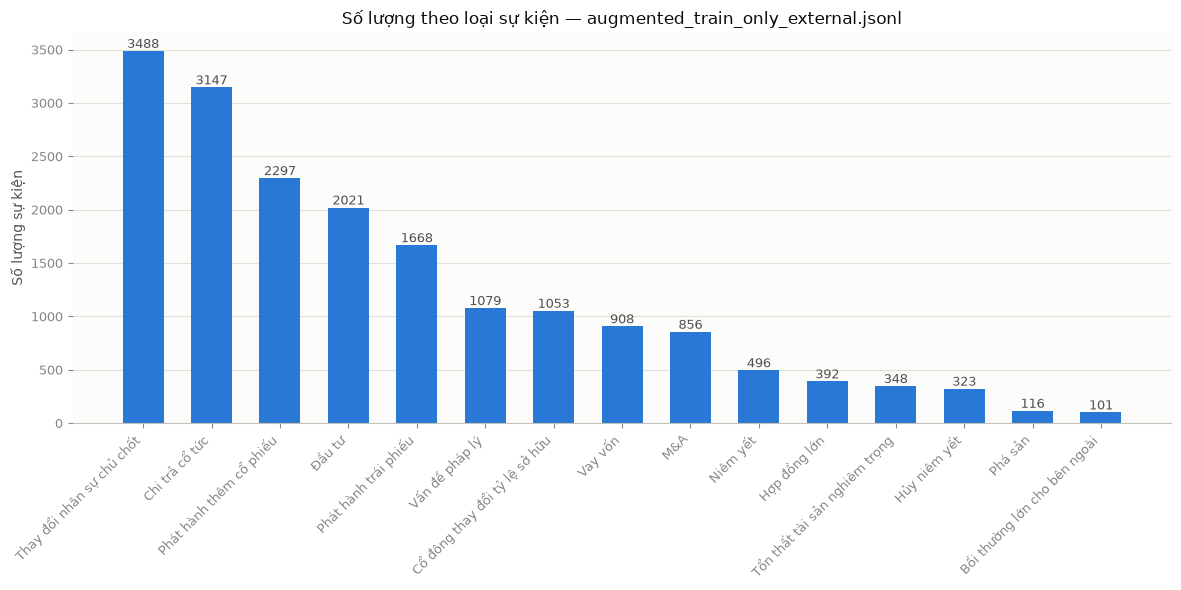

In [17]:
PROJECT_DIR  = Path.cwd().parent
FILE  = PROJECT_DIR / "data/processed/augmented_train_only_external.jsonl"

plot_event_type_counts(FILE, all_events=all_events)

## So sánh số lượng mẫu có sự kiện và không có sự kiện

### Config & Code

In [15]:
def plot_event_vs_no_event_counts(jsonl_path: str | Path, figsize: tuple = (5, 5.5)) -> None:
    """
    - Summary: Vẽ bar chart so sánh mẫu có/không có sự kiện.
    - Args:
        - jsonl_path: Đường dẫn file JSONL đã format (có field "events").
        - figsize:    Kích thước biểu đồ (width, height).
    - Output:
        - None. Hiển thị bar chart so sánh mẫu có/không có sự kiện.
    """
    # Bảng màu tham chiếu (dataviz skill — references/palette.md)
    ink_primary   = "#0b0b0b"
    ink_secondary = "#52514e"
    ink_muted     = "#898781"
    gridline      = "#e1e0d9"
    baseline      = "#c3c2b7"
    surface       = "#fcfcfb"
    seq_blue      = "#2a78d6"  # categorical slot 1
    cat_aqua      = "#1baf7a"  # categorical slot 2

    records: list[dict] = []
    with Path(jsonl_path).open(encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    records.append(json.loads(line))
                except Exception:
                    pass

    has_event_count = sum(1 for record in records if record.get("events"))
    no_event_count  = len(records) - has_event_count

    labels = ['Có ít nhất 1 sự kiện', 'Không có sự kiện']
    values = [has_event_count, no_event_count]
    colors = [seq_blue, cat_aqua]

    fig, ax = plt.subplots(figsize=figsize)
    bars    = ax.bar(labels, values, color=colors, width=0.5)

    for bar, value in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), str(value),
                 ha='center', va='bottom', fontsize=10, color=ink_secondary)

    ax.set_facecolor(surface)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(baseline)
    ax.yaxis.grid(True, color=gridline, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(axis="both", colors=ink_muted, labelsize=9)

    ax.set_ylabel('Số lượng mẫu', color=ink_secondary)
    ax.set_title(f'Mẫu có/không có sự kiện — {Path(jsonl_path).name}', color=ink_primary, fontsize=12)

    fig.tight_layout()
    plt.show()

### Run

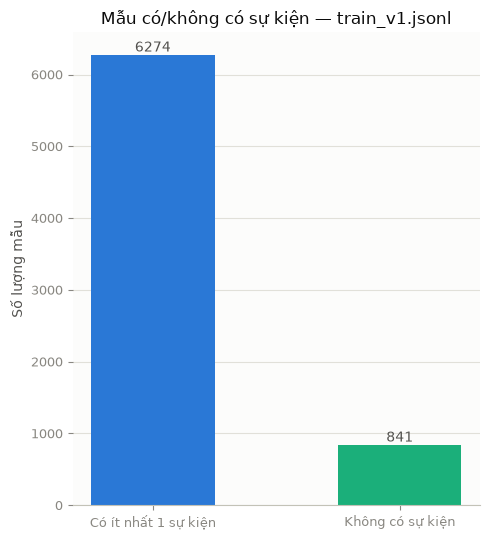

In [16]:
PROJECT_DIR  = Path.cwd().parent
SAMPLE_FILE  = PROJECT_DIR / "data/processed/train_v1.jsonl"

plot_event_vs_no_event_counts(SAMPLE_FILE)